# PDD Mobility Scanner — Video + Sensor Sync & Object Detection

Upload `trail_data.csv` and `trail_video.mp4` from the SD card.
This notebook:
1. Syncs video frames to CSV sensor data using `rec_start_ms`
2. Runs YOLO object detection on each frame
3. Shows a detection timeline so you can see what was found
4. Lets you select which classes to track as obstacles
5. Shows annotated frames for the selected classes
6. Groups selected detections into **encounters**, keeping only the peak bbox frame
7. Exports `detections_peak.csv` (one row per obstacle) and `detections.csv` (all frames)

## Step 1: Install dependencies

In [56]:
!pip install -q ultralytics
import pandas as pd
import numpy as np
import cv2
import math
from ultralytics import YOLO
from google.colab import files
from IPython.display import display, Image as IPImage
import matplotlib.pyplot as plt
import os

## Step 2: Upload files

In [57]:
print('Upload trail_data.csv and trail_video.mp4')
uploaded = files.upload()

csv_file = [f for f in uploaded.keys() if f.endswith('.csv')][0]
video_file = [f for f in uploaded.keys() if f.endswith('.mp4')][0]
print(f'CSV: {csv_file}')
print(f'Video: {video_file}')

Upload trail_data.csv and trail_video.mp4


Saving trail_video.mp4 to trail_video (4).mp4
Saving trail_data.csv to trail_data (4).csv
CSV: trail_data (4).csv
Video: trail_video (4).mp4


## Step 3: Load CSV and extract rec_start_ms

GPS only appears on rows where a fresh fix arrived (~1 Hz). Forward-fill so every row carries the most recent GPS position.

In [58]:
with open(csv_file) as f:
    first_line = f.readline().strip()
rec_start_ms = int(first_line.split('=')[1])
print(f'Video recording started at ms={rec_start_ms}')

df = pd.read_csv(csv_file, comment='#')

gps_cols = ['utc', 'lat', 'lng', 'alt', 'speed', 'hdg', 'sats', 'hdop']
df[gps_cols] = df[gps_cols].ffill()

df['video_sec'] = (df['ms'] - rec_start_ms) / 1000.0

total_rows = len(df)
gps_rows = df['lat'].notna().sum()
dur = df['video_sec'].max()
print(f'Loaded {total_rows} sensor rows')
print(f'Recording duration: {dur:.1f}s')
print(f'Rows with GPS after forward-fill: {gps_rows}/{total_rows}')
df[['ms', 'video_sec', 'utc', 'lat', 'lng']].head(10)

Video recording started at ms=1775934928760
Loaded 19 sensor rows
Recording duration: 14.3s
Rows with GPS after forward-fill: 19/19


,ms,video_sec,utc,lat,lng
0,1775934928788,0.028,2026-04-11T19:15:20.156Z,41.822923,-71.394065
1,1775934928801,0.041,2026-04-11T19:15:28.782Z,41.822923,-71.394065
2,1775934928801,0.041,2026-04-11T19:15:28.782Z,41.822886,-71.394706
3,1775934928879,0.119,2026-04-11T19:15:28.856Z,41.822885,-71.394698
4,1775934929693,0.933,2026-04-11T19:15:29.628Z,41.822968,-71.394449
5,1775934930060,1.300,2026-04-11T19:15:30.018Z,41.823032,-71.394328
6,1775934931035,2.275,2026-04-11T19:15:31.021Z,41.823051,-71.394324
7,1775934932037,3.277,2026-04-11T19:15:32.022Z,41.823037,-71.394289
8,1775934933038,4.278,2026-04-11T19:15:33.023Z,41.823039,-71.394270
9,1775934934033,5.273,2026-04-11T19:15:34.019Z,41.823045,-71.394256


## Step 4: Extract video frames and sync to sensor data

For each video frame, find the closest sensor row by timestamp to get GPS + IMU data.

In [59]:
cap = cv2.VideoCapture(video_file)
fps = cap.get(cv2.CAP_PROP_FPS)
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
print(f'Video: {total_frames} frames at {fps} FPS ({total_frames/fps:.1f}s)')

os.makedirs('frames', exist_ok=True)
frames = []
frame_idx = 0

while True:
    ret, frame = cap.read()
    if not ret:
        break

    video_sec = frame_idx / fps
    ms_at_frame = rec_start_ms + int(video_sec * 1000)

    closest_idx = (df['ms'] - ms_at_frame).abs().idxmin()
    row = df.loc[closest_idx]

    frames.append({
        'frame': frame_idx,
        'video_sec': video_sec,
        'ms': ms_at_frame,
        'sensor_ms': row['ms'],
        'sync_offset_ms': abs(row['ms'] - ms_at_frame),
        'utc': row.get('utc', ''),
        'lat': row.get('lat', np.nan),
        'lng': row.get('lng', np.nan),
        'alt': row.get('alt', np.nan),
        'speed': row.get('speed', np.nan),
    })

    cv2.imwrite(f'frames/frame_{frame_idx:04d}.jpg', frame)
    frame_idx += 1

cap.release()

frames_df = pd.DataFrame(frames)
print(f'Extracted {len(frames_df)} frames')
print(f'Average sync offset: {frames_df["sync_offset_ms"].mean():.1f}ms')
frames_df.head(10)

Video: 436 frames at 29.982808022922637 FPS (14.5s)
Extracted 436 frames
Average sync offset: 238.8ms


,frame,video_sec,ms,sensor_ms,sync_offset_ms,utc,lat,lng,alt,speed
0,0,0.000000,1775934928760,1775934928788,28,2026-04-11T19:15:20.156Z,41.822923,-71.394065,27.232258,0.0
1,1,0.033352,1775934928793,1775934928788,5,2026-04-11T19:15:20.156Z,41.822923,-71.394065,27.232258,0.0
2,2,0.066705,1775934928826,1775934928801,25,2026-04-11T19:15:28.782Z,41.822923,-71.394065,27.232258,0.0
3,3,0.100057,1775934928860,1775934928879,19,2026-04-11T19:15:28.856Z,41.822885,-71.394698,27.261716,0.0
4,4,0.133410,1775934928893,1775934928879,14,2026-04-11T19:15:28.856Z,41.822885,-71.394698,27.261716,0.0
5,5,0.166762,1775934928926,1775934928879,47,2026-04-11T19:15:28.856Z,41.822885,-71.394698,27.261716,0.0
6,6,0.200115,1775934928960,1775934928879,81,2026-04-11T19:15:28.856Z,41.822885,-71.394698,27.261716,0.0
7,7,0.233467,1775934928993,1775934928879,114,2026-04-11T19:15:28.856Z,41.822885,-71.394698,27.261716,0.0
8,8,0.266820,1775934929026,1775934928879,147,2026-04-11T19:15:28.856Z,41.822885,-71.394698,27.261716,0.0
9,9,0.300172,1775934929060,1775934928879,181,2026-04-11T19:15:28.856Z,41.822885,-71.394698,27.261716,0.0


## Step 5: Run YOLO object detection on each frame

Tune `CONF_THRESHOLD` to cut low-confidence detections before they reach any downstream steps.
Default YOLO threshold is 0.25 — raising it to 0.4 removes most spurious single-frame hits.

In [60]:
CONF_THRESHOLD = 0.75  # raise to reduce spurious detections (YOLO default is 0.25)

model = YOLO('yolov8n.pt')

detections = []

for i, row in frames_df.iterrows():
    img_path = f'frames/frame_{row["frame"]:04d}.jpg'
    results = model(img_path, verbose=False, conf=CONF_THRESHOLD)

    frame_objects = []
    for r in results:
        for box in r.boxes:
            cls_name = model.names[int(box.cls)]
            conf = float(box.conf)
            frame_objects.append({
                'frame': row['frame'],
                'video_sec': row['video_sec'],
                'utc': row['utc'],
                'lat': row['lat'],
                'lng': row['lng'],
                'object': cls_name,
                'confidence': conf,
                'bbox': box.xyxy[0].tolist(),
            })

    if not frame_objects:
        detections.append({
            'frame': row['frame'],
            'video_sec': row['video_sec'],
            'utc': row['utc'],
            'lat': row['lat'],
            'lng': row['lng'],
            'object': None,
            'confidence': None,
            'bbox': None,
        })
    else:
        detections.extend(frame_objects)

    if (i + 1) % 10 == 0:
        print(f'Processed {i + 1}/{len(frames_df)} frames...')

det_df = pd.DataFrame(detections)
obj_timeline = det_df[det_df['object'].notna()].copy()
print(f'\nTotal detections: {len(obj_timeline)}')
print(f'Unique object types: {obj_timeline["object"].nunique()}')

Processed 10/436 frames...
Processed 20/436 frames...
Processed 30/436 frames...
Processed 40/436 frames...
Processed 50/436 frames...
Processed 60/436 frames...
Processed 70/436 frames...
Processed 80/436 frames...
Processed 90/436 frames...
Processed 100/436 frames...
Processed 110/436 frames...
Processed 120/436 frames...
Processed 130/436 frames...
Processed 140/436 frames...
Processed 150/436 frames...
Processed 160/436 frames...
Processed 170/436 frames...
Processed 180/436 frames...
Processed 190/436 frames...
Processed 200/436 frames...
Processed 210/436 frames...
Processed 220/436 frames...
Processed 230/436 frames...
Processed 240/436 frames...
Processed 250/436 frames...
Processed 260/436 frames...
Processed 270/436 frames...
Processed 280/436 frames...
Processed 290/436 frames...
Processed 300/436 frames...
Processed 310/436 frames...
Processed 320/436 frames...
Processed 330/436 frames...
Processed 340/436 frames...
Processed 350/436 frames...
Processed 360/436 frames...
P

## Step 6: Detection timeline

See what was detected and when — before any class filtering.

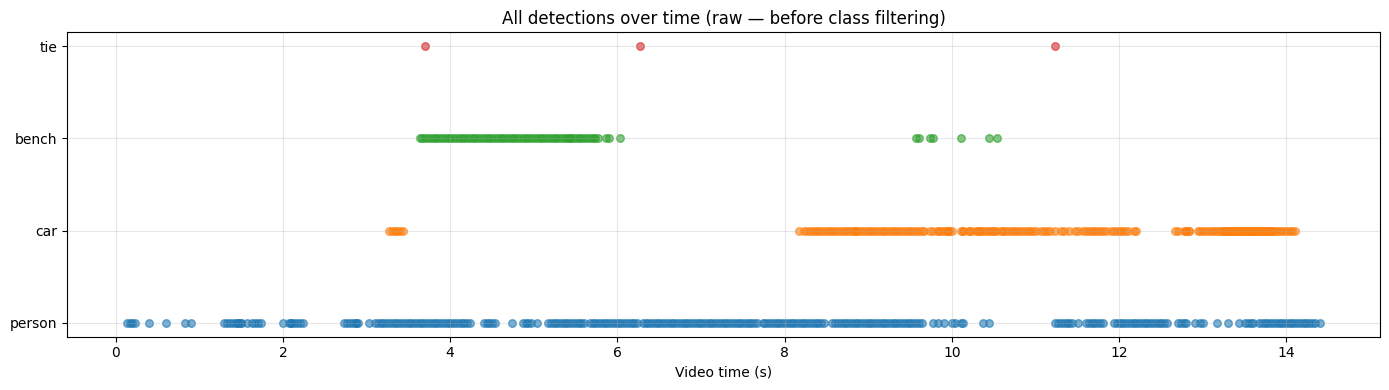

In [61]:
if len(obj_timeline) > 0:
    all_objects = obj_timeline['object'].value_counts().index
    fig, ax = plt.subplots(figsize=(14, max(4, len(all_objects) * 0.4)))
    for obj_name in all_objects:
        obj_rows = obj_timeline[obj_timeline['object'] == obj_name]
        ax.scatter(obj_rows['video_sec'], [obj_name] * len(obj_rows),
                   alpha=0.6, s=30)
    ax.set_xlabel('Video time (s)')
    ax.set_title('All detections over time (raw — before class filtering)')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print('No objects detected.')

## Step 7: Select obstacle classes

Only classes that appear in at least `MIN_ENCOUNTER_FRAMES` total frames are listed —
anything below that threshold is already filtered out as noise.

Edit `KEEP_CLASSES` to choose which of the remaining classes get written to `detections_peak.csv`.

In [63]:
MIN_ENCOUNTER_FRAMES = 3  # minimum frames for a detection or encounter to be considered real

# Only show classes that clear the minimum frame threshold
class_counts = det_df['object'].value_counts()
stable_classes = class_counts[class_counts >= MIN_ENCOUNTER_FRAMES]

print(f'Classes with >= {MIN_ENCOUNTER_FRAMES} detections (noise filtered):')
print(stable_classes.to_string())
print()
filtered_out = class_counts[class_counts < MIN_ENCOUNTER_FRAMES]
if len(filtered_out) > 0:
    print(f'Filtered out as noise (< {MIN_ENCOUNTER_FRAMES} frames): {sorted(filtered_out.index.tolist())}')
print()

# =====================================================
# EDIT THIS LIST — add any class name from above
KEEP_CLASSES = [
    'bench',
    'car',
]
# =====================================================

detected_stable = set(stable_classes.index)
unknown = set(KEEP_CLASSES) - detected_stable
if unknown:
    print(f'Warning: not in stable detections: {sorted(unknown)}')

kept = [c for c in KEEP_CLASSES if c in detected_stable]
if not kept:
    print('No valid classes selected — edit KEEP_CLASSES and re-run this cell.')
else:
    skipped = sorted(detected_stable - set(kept))
    print(f'Tracking:  {kept}')
    if skipped:
        print(f'Skipping:  {skipped}')

Classes with >= 3 detections (noise filtered):
object
person    294
car       184
bench      76
tie         3


Tracking:  ['bench', 'car']
Skipping:  ['person', 'tie']


## Step 8: Annotated frames

Sample frames containing detections from the selected classes only.

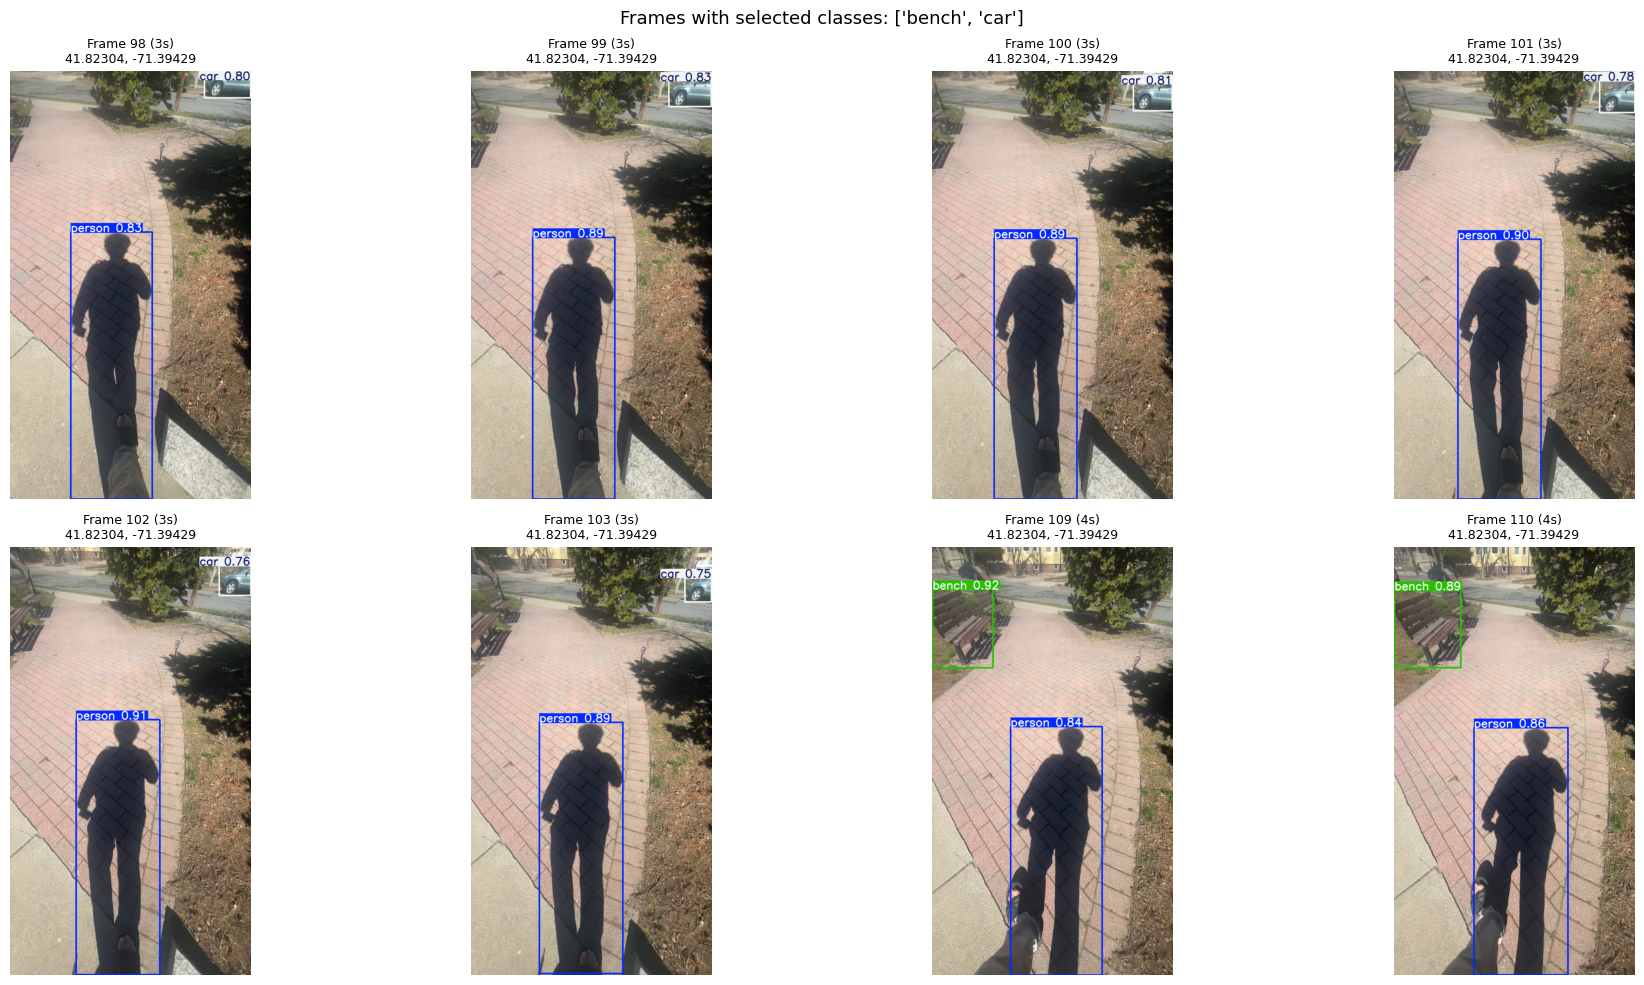

In [64]:
frames_with_selected = det_df[det_df['object'].isin(KEEP_CLASSES)]['frame'].unique()
sample_frames = frames_with_selected[:8]

if len(sample_frames) == 0:
    print('No frames found for selected classes.')
else:
    cols = min(4, len(sample_frames))
    rows = (len(sample_frames) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 5 * rows))
    axes = np.array(axes).flatten()

    for i, frame_num in enumerate(sample_frames):
        img_path = f'frames/frame_{frame_num:04d}.jpg'
        results = model(img_path, verbose=False, conf=CONF_THRESHOLD)
        annotated = results[0].plot()
        frame_info = frames_df[frames_df['frame'] == frame_num].iloc[0]
        lat = frame_info['lat']
        lng = frame_info['lng']
        sec = frame_info['video_sec']
        axes[i].imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
        title = f'Frame {frame_num} ({sec:.0f}s)'
        if pd.notna(lat):
            title += f'\n{lat:.5f}, {lng:.5f}'
        axes[i].set_title(title, fontsize=9)
        axes[i].axis('off')

    for j in range(len(sample_frames), len(axes)):
        axes[j].axis('off')

    plt.suptitle(f'Frames with selected classes: {KEEP_CLASSES}', fontsize=13)
    plt.tight_layout()
    plt.show()

## Step 9: Encounter grouping — peak detection per obstacle

Group consecutive detections of the same class into encounters. Keep only the frame
with the **largest bounding box** (closest approach) as the single CSV row per obstacle.

Encounters shorter than `MIN_ENCOUNTER_FRAMES` are discarded as noise.

In [65]:
MAX_GAP_FRAMES = 9  # consecutive missed frames still counted as same encounter


def bbox_area(bbox):
    """Pixel area of a [x1, y1, x2, y2] bounding box."""
    if bbox is None:
        return 0
    x1, y1, x2, y2 = bbox
    return (x2 - x1) * (y2 - y1)


def find_encounter_peaks(det_df, max_gap=MAX_GAP_FRAMES, min_frames=MIN_ENCOUNTER_FRAMES):
    """
    Group consecutive same-class detections into encounters.
    Discard encounters shorter than min_frames.
    Return one row per valid encounter: the frame with the largest bounding box.
    """
    only_dets = det_df[det_df['object'].notna()].copy()
    only_dets['_area'] = only_dets['bbox'].apply(bbox_area)

    peaks = []
    enc_id = 0
    dropped = 0

    for cls_name in sorted(only_dets['object'].unique()):
        cls_rows = only_dets[only_dets['object'] == cls_name].sort_values('frame')

        group = []
        prev_frame = None

        for _, row in cls_rows.iterrows():
            if prev_frame is None or (row['frame'] - prev_frame) <= max_gap + 1:
                group.append(row)
            else:
                if len(group) >= min_frames:
                    peak = max(group, key=lambda r: r['_area'])
                    peaks.append({
                        'encounter_id': enc_id,
                        'encounter_frames': len(group),
                        'frame': int(peak['frame']),
                        'video_sec': peak['video_sec'],
                        'utc': peak['utc'],
                        'lat': peak['lat'],
                        'lng': peak['lng'],
                        'object': cls_name,
                        'confidence': round(float(peak['confidence']), 4),
                        'bbox_area_px': int(peak['_area']),
                    })
                    enc_id += 1
                else:
                    dropped += 1
                    print(f'  Dropped {cls_name} group: {len(group)} frame(s) '
                          f'at frames {int(group[0]["frame"])}–{int(group[-1]["frame"])}')
                group = [row]
            prev_frame = row['frame']

        # Flush final group
        if group:
            if len(group) >= min_frames:
                peak = max(group, key=lambda r: r['_area'])
                peaks.append({
                    'encounter_id': enc_id,
                    'encounter_frames': len(group),
                    'frame': int(peak['frame']),
                    'video_sec': peak['video_sec'],
                    'utc': peak['utc'],
                    'lat': peak['lat'],
                    'lng': peak['lng'],
                    'object': cls_name,
                    'confidence': round(float(peak['confidence']), 4),
                    'bbox_area_px': int(peak['_area']),
                })
                enc_id += 1
            else:
                dropped += 1
                print(f'  Dropped {cls_name} group: {len(group)} frame(s) '
                      f'at frames {int(group[0]["frame"])}–{int(group[-1]["frame"])}')

    if dropped > 0:
        print(f'Dropped {dropped} short encounter(s) (< {min_frames} frames)')

    if not peaks:
        return pd.DataFrame(columns=[
            'encounter_id', 'encounter_frames', 'frame', 'video_sec',
            'utc', 'lat', 'lng', 'object', 'confidence', 'bbox_area_px'
        ])
    return pd.DataFrame(peaks)


det_filtered = det_df[det_df['object'].isin(KEEP_CLASSES)].copy()
peaks_df = find_encounter_peaks(det_filtered)

raw_count = det_filtered['object'].notna().sum()
print(f'Raw detections (selected classes):  {raw_count} rows')
print(f'Peak detections:                    {len(peaks_df)} rows  ({raw_count - len(peaks_df)} removed)')
if len(peaks_df) > 0:
    print()
    print(peaks_df[['encounter_id', 'object', 'encounter_frames', 'video_sec',
                     'confidence', 'bbox_area_px', 'lat', 'lng']].to_string(index=False))

Raw detections (selected classes):  260 rows
Peak detections:                    5 rows  (255 removed)

 encounter_id object  encounter_frames  video_sec  confidence  bbox_area_px       lat        lng
            0  bench                69   5.769973      0.7684        338700 41.823045 -71.394256
            1  bench                 7   9.772267      0.8626        328571 41.823071 -71.394199
            2    car                 6   3.301892      0.8345         29258 41.823037 -71.394289
            3    car               116   8.471521      0.8678         51149 41.823066 -71.394215
            4    car                62  13.140864      0.9392        174705 41.823104 -71.394159


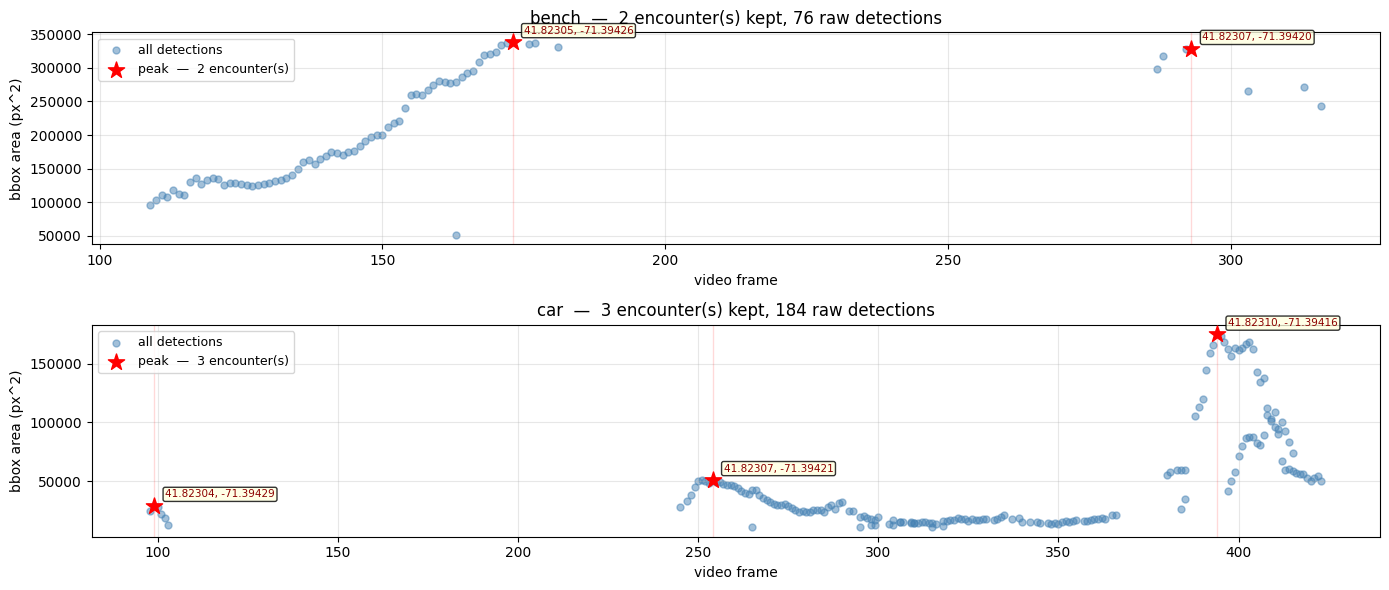

In [67]:
# Bbox area trajectory — blue dots are all raw detections, red stars are peak frames.
# GPS coordinates are shown on each peak; distance in metres between consecutive peaks
# of the same class is shown between them.


def haversine_m(lat1, lon1, lat2, lon2):
    """Straight-line distance in metres between two GPS coordinates."""
    R = 6_371_000
    phi1, phi2 = math.radians(lat1), math.radians(lat2)
    dphi = math.radians(lat2 - lat1)
    dlam = math.radians(lon2 - lon1)
    a = math.sin(dphi / 2) ** 2 + math.cos(phi1) * math.cos(phi2) * math.sin(dlam / 2) ** 2
    return R * 2 * math.atan2(math.sqrt(a), math.sqrt(1 - a))


if len(obj_timeline) > 0 and len(det_filtered[det_filtered['object'].notna()]) > 0:
    only_dets = det_filtered[det_filtered['object'].notna()].copy()
    only_dets['_area'] = only_dets['bbox'].apply(bbox_area)

    classes = sorted(only_dets['object'].unique())
    fig, axes = plt.subplots(len(classes), 1, figsize=(14, 3 * len(classes)), squeeze=False)

    for i, cls_name in enumerate(classes):
        ax = axes[i][0]
        cls_dets = only_dets[only_dets['object'] == cls_name].sort_values('frame')
        cls_peaks = peaks_df[peaks_df['object'] == cls_name] if len(peaks_df) > 0 else pd.DataFrame()

        ax.scatter(cls_dets['frame'], cls_dets['_area'],
                   alpha=0.5, s=25, color='steelblue', label='all detections')

        if len(cls_peaks) > 0:
            ax.scatter(cls_peaks['frame'], cls_peaks['bbox_area_px'],
                       s=150, marker='*', color='red', zorder=5,
                       label=f'peak  —  {len(cls_peaks)} encounter(s)')

            for _, p_row in cls_peaks.iterrows():
                ax.axvline(p_row['frame'], color='red', alpha=0.15, linewidth=1)
                # GPS label on each peak
                lat, lng = p_row['lat'], p_row['lng']
                gps_label = f'{lat:.5f}, {lng:.5f}' if pd.notna(lat) and pd.notna(lng) else 'no GPS'
                ax.annotate(gps_label,
                            xy=(p_row['frame'], p_row['bbox_area_px']),
                            xytext=(8, 6), textcoords='offset points',
                            fontsize=7.5, color='darkred',
                            bbox=dict(boxstyle='round,pad=0.2', fc='lightyellow', alpha=0.8))

        n_enc = len(cls_peaks)
        n_raw = len(cls_dets)
        ax.set_title(f'{cls_name}  —  {n_enc} encounter(s) kept, {n_raw} raw detections')
        ax.set_xlabel('video frame')
        ax.set_ylabel('bbox area (px^2)')
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
else:
    print('No detections to visualize.')

## Step 10: Export results

In [ ]:
# Full detection log — every detection on every frame (all classes, unchanged)
export = det_df.drop(columns=['bbox']).copy()
export.to_csv('detections.csv', index=False)
print(f'Saved detections.csv         ({len(export)} rows — all frames, all classes)')

# Peak-filtered — one row per obstacle encounter, selected classes only
peaks_df.to_csv('detections_peak.csv', index=False)
print(f'Saved detections_peak.csv    ({len(peaks_df)} rows — one per encounter, classes: {KEEP_CLASSES})')

# Geolocated frame summary (all classes)
gps_objects = obj_timeline.dropna(subset=['lat', 'lng']).groupby(
    ['frame', 'video_sec', 'lat', 'lng']
)['object'].apply(list).reset_index()
gps_objects.columns = ['frame', 'video_sec', 'lat', 'lng', 'objects']
gps_objects.to_csv('gps_detections.csv', index=False)
print(f'Saved gps_detections.csv     ({len(gps_objects)} geolocated frames)')

files.download('detections.csv')
files.download('detections_peak.csv')
files.download('gps_detections.csv')

gps_objects.head(10)